## NumPy, Pandas - exercises
### BIOINF 575



___

#### Processing the worm genome file - using pandas
You will do a quick exploration of the data in the the GFF3 file for the C. elegans genome. The GFF3 file is `Caenorhabditis_elegans.WBcel235.91.gff3` and is also available in the github repository (you should have it in the study session if you updated the repo). The GFF3 format is described on:
https://github.com/The-Sequence-Ontology/Specifications/blob/master/gff3.md.<br> 

After the comment and header lines (marked by "#"), a line in a GFF3 file (row of a table) is composed of 9 tab-delimited fields (columns). The first 8 are called features. These are all atomic (consist of only one element), so they get put into a dictionary features with no problems. You will need to define a key and you will have to generate those integers as you read the file in and add data to the dictionary.

The ninth field will pose more of a problem. It consists of tag-value pairs. **The tag-value pairs are separated by a semi-colon, ";". The the tag and value in a pair are  separated by equal signs, "=", and the values may consist of mulitiple, comma, ",", separated entries.** Also, any value may be encoded as html-safe encoding. Caution: the encoded characters may be the same as those used to separate the components of the attributes field. To get rid of the encoding (these are  pairs of characters or digits preceded by the % sign), use the unquote() function from urllib.parse (`from urllib.parse import unquote`). Just be careful of when you use it - do it at the wrong time and you will mess up the parsing of attributes.

From the definition of the GFF3 we have these fields

Each line contains the following information for a genomic features:  `seqid, source, type, start, end, score, strand, phase, attributes`.


The attributes column contains the following information: ;-separated pairs of tag=value, where the values may consist of mulitiple, comma, ",", separated entries.




____

### <font color = "red">Exercise</font>

#### - Load data from the file and get it ready for analysis:
- Open the `Caenorhabditis_elegans.WBcel235.91.gff3` and check the format.
- Read the data from the `Caenorhabditis_elegans.WBcel235.91.gff3` into a dataframe.
- Set the column names to: ` seqid, source, type, start, end, score, strand, phase, attributes`. 
- Set the row names to: `Feature0, ..., FeatureX, ... FeatureN`, where X is the row index and N the number of rows.




In [18]:
import numpy as np
import pandas as pd

df_features = pd.read_csv('/Users/laurel/Desktop/bioinfor575/bioinf575/session_11_numpy_pandas/Caenorhabditis_elegans.WBcel235.91.gff3', sep='\t', comment='#',header=None)
nrows = df_features.shape[0]
ncols = df_features.shape[1]
print(nrows)
print(ncols)

col_labels = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
df_features.columns = col_labels
row_labels = ['feature' + str(i+1) for i in range(nrows)]
df_features.index = row_labels



#help(pd.read_csv)

# Also you can use the: contextual help 
# right click the notebook select > show contextual help
# select the tab of the contextual help from the tabs of the opened files
# drag and drop it to the right of your notebook window
# you should have something that looks like a split screen 
# with your notebook to the left anf the contextual help window on the right
# now on a cell in the notebook write a function name like abs, or print 
# - the help for the function should show in the right window  (contextual help window)



659621
9


In [19]:
df_features.head()

,seqid,source,type,start,end,score,strand,phase,attributes
feature1,I,WormBase,chromosome,1,15072434,.,.,.,"ID=chromosome:I;Alias=BX284601.5,NC_003279.8"
feature2,I,WormBase,ncRNA_gene,3747,3909,.,-,.,ID=gene:WBGene00023193;Name=Y74C9A.6;biotype=s...
feature3,I,WormBase,snoRNA,3747,3909,.,-,.,ID=transcript:Y74C9A.6;Parent=gene:WBGene00023...
feature4,I,WormBase,exon,3747,3909,.,-,.,Parent=transcript:Y74C9A.6;Name=Y74C9A.6.e1;co...
feature5,I,WormBase,gene,4116,10230,.,-,.,ID=gene:WBGene00022277;Name=homt-1;biotype=pro...


In [ ]:
df_features.T

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10,...,feature659612,feature659613,feature659614,feature659615,feature659616,feature659617,feature659618,feature659619,feature659620,feature659621
seqid,I,I,I,I,I,I,I,I,I,I,...,X,X,X,X,X,X,X,X,X,X
source,WormBase,WormBase,WormBase,WormBase,WormBase,WormBase,WormBase,WormBase,WormBase,WormBase,...,WormBase,WormBase,WormBase,WormBase,WormBase,WormBase,WormBase,WormBase,WormBase,WormBase
type,chromosome,ncRNA_gene,snoRNA,exon,gene,mRNA,three_prime_UTR,exon,CDS,exon,...,CDS,exon,CDS,exon,CDS,exon,CDS,CDS,exon,three_prime_UTR
start,1,3747,3747,3747,4116,4116,4116,4116,4221,5195,...,17714968,17716974,17716974,17717171,17717171,17717328,17717328,17718435,17718435,17718622
end,15072434,3909,3909,3909,10230,10230,4220,4358,4358,5296,...,17715111,17717087,17717087,17717278,17717278,17717443,17717443,17718621,17718720,17718720
score,.,.,.,.,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
strand,.,-,-,-,-,-,-,-,-,-,...,+,+,+,+,+,+,+,+,+,+
phase,.,.,.,.,.,.,.,.,0,.,...,0,.,0,.,0,.,0,1,.,.
attributes,"ID=chromosome:I;Alias=BX284601.5,NC_003279.8",ID=gene:WBGene00023193;Name=Y74C9A.6;biotype=s...,ID=transcript:Y74C9A.6;Parent=gene:WBGene00023...,Parent=transcript:Y74C9A.6;Name=Y74C9A.6.e1;co...,ID=gene:WBGene00022277;Name=homt-1;biotype=pro...,ID=transcript:Y74C9A.3;Parent=gene:WBGene00022...,Parent=transcript:Y74C9A.3,Parent=transcript:Y74C9A.3;Name=Y74C9A.3.e5;co...,ID=CDS:Y74C9A.3;Parent=transcript:Y74C9A.3;pro...,Parent=transcript:Y74C9A.3;Name=Y74C9A.3.e4;co...,...,ID=CDS:cTel55X.1a;Parent=transcript:cTel55X.1a...,Parent=transcript:cTel55X.1a;Name=cTel55X.1a.e...,ID=CDS:cTel55X.1a;Parent=transcript:cTel55X.1a...,Parent=transcript:cTel55X.1a;Name=cTel55X.1a.e...,ID=CDS:cTel55X.1a;Parent=transcript:cTel55X.1a...,Parent=transcript:cTel55X.1a;Name=cTel55X.1a.e...,ID=CDS:cTel55X.1a;Parent=transcript:cTel55X.1a...,ID=CDS:cTel55X.1a;Parent=transcript:cTel55X.1a...,Parent=transcript:cTel55X.1a;Name=cTel55X.1a.e...,Parent=transcript:cTel55X.1a


___

### - Compute how many types of genomic features there are in our dataset and how many features of each kind. (e.g.: gene, exon, mRNA in the third column in the file are feature types)


#### If you are trying to do a common operation on a dataframe or Series (dataframe column) it may have already been implemented - look for a function that does what you need in the documentation.

Useful links to see the attributes (variables, properties) and methods (functions) a column of a pandas dataframe (Series) and a pandas dataframe has:    
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html  
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html

In [20]:
# pandas.core.series.Series.nunique(dropna: bool = True) -> int
# Returns the number of unique elements in the object.
# Excludes NA values by default.

# To get the number of unique values in a column, you can use the nunique() method on a Series.
# For example, to get the number of unique values in the 'type' column:
unique_types = df_features['type'].nunique()
print(unique_types)





19


In [21]:
#pandas.core.series.Series.value_counts(
#    normalize=False,
#    sort=True,
#    ascending=False,
#    bins=None,
#    dropna=True,
#)

#Returns a Series containing counts of unique values.
# The resulting object will be in descending order so that the
# first element is the most frequently-occurring element.
# Excludes NA values by default.


df_features.type.value_counts()

type
exon                      269904
CDS                       222859
mRNA                       33391
five_prime_UTR             30960
three_prime_UTR            28004
ncRNA_gene                 24765
gene                       20222
piRNA                      15364
ncRNA                       8402
pseudogenic_transcript      1827
pseudogene                  1791
tRNA                         634
miRNA                        454
snoRNA                       345
lnc_RNA                      283
pre_miRNA                    257
snRNA                        130
rRNA                          22
chromosome                     7
Name: count, dtype: int64

___

### - Plot the distribution (histogram) of the length of the genomich features in the file

In [22]:
df_features.head()


,seqid,source,type,start,end,score,strand,phase,attributes
feature1,I,WormBase,chromosome,1,15072434,.,.,.,"ID=chromosome:I;Alias=BX284601.5,NC_003279.8"
feature2,I,WormBase,ncRNA_gene,3747,3909,.,-,.,ID=gene:WBGene00023193;Name=Y74C9A.6;biotype=s...
feature3,I,WormBase,snoRNA,3747,3909,.,-,.,ID=transcript:Y74C9A.6;Parent=gene:WBGene00023...
feature4,I,WormBase,exon,3747,3909,.,-,.,Parent=transcript:Y74C9A.6;Name=Y74C9A.6.e1;co...
feature5,I,WormBase,gene,4116,10230,.,-,.,ID=gene:WBGene00022277;Name=homt-1;biotype=pro...


<Axes: >

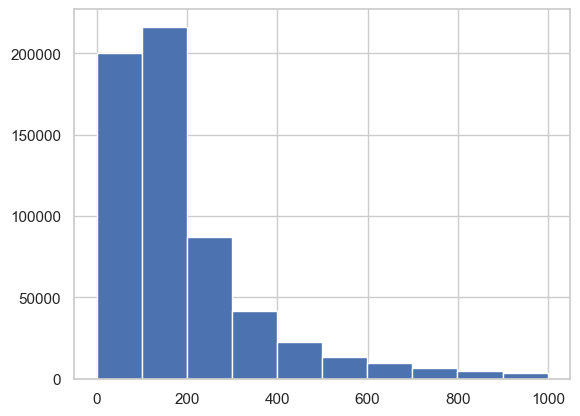

In [23]:
flength = df_features.end - df_features.start
flength[flength < 1000].hist()

In [24]:
df_features.type[flength >=100000].unique() 

array(['chromosome', 'gene', 'mRNA'], dtype=object)

_____ 

### - Find the genes between positions: 4000 and 10000.
    - Hint: start and end (4th and 5th columns in the file) need to be between these numbers.

In [25]:
# conditional subsetting to select rows that meet the condition
# combine condition using & (bit-wise and operator) 
# use parantheses to evaluate the condition first 
# parantheses are needed because & has higher precedence than comparison operators (>, < , ==, ...)
c1 = df_features.type == 'gene'
c2 = df_features.start > 4000
c3 = df_features.end < 100000

gene_df =df_features[c1 & c2 & c3]
gene_df.head()



,seqid,source,type,start,end,score,strand,phase,attributes
feature5,I,WormBase,gene,4116,10230,.,-,.,ID=gene:WBGene00022277;Name=homt-1;biotype=pro...
feature19,I,WormBase,gene,11495,16837,.,+,.,ID=gene:WBGene00022276;Name=nlp-40;biotype=pro...
feature83,I,WormBase,gene,17487,26781,.,-,.,ID=gene:WBGene00022278;Name=rcor-1;biotype=pro...
feature182,I,WormBase,gene,27591,32544,.,-,.,ID=gene:WBGene00022279;Name=sesn-1;biotype=pro...
feature202,I,WormBase,gene,43733,44677,.,+,.,ID=gene:WBGene00022275;Name=Y74C9A.1;biotype=p...


In [26]:
# Conditional subsetting to retrieve rows that meet the condition
# we use .loc attribute when we want to also subset the columns

gene_df.loc[:, ['seqid', 'start', 'end', 'attributes']].head()

,seqid,start,end,attributes
feature5,I,4116,10230,ID=gene:WBGene00022277;Name=homt-1;biotype=pro...
feature19,I,11495,16837,ID=gene:WBGene00022276;Name=nlp-40;biotype=pro...
feature83,I,17487,26781,ID=gene:WBGene00022278;Name=rcor-1;biotype=pro...
feature182,I,27591,32544,ID=gene:WBGene00022279;Name=sesn-1;biotype=pro...
feature202,I,43733,44677,ID=gene:WBGene00022275;Name=Y74C9A.1;biotype=p...


In [27]:
gene_df.loc[:, "type":"end"].head()

,type,start,end
feature5,gene,4116,10230
feature19,gene,11495,16837
feature83,gene,17487,26781
feature182,gene,27591,32544
feature202,gene,43733,44677


____

We have a file with the gene expression for 45h every three hours for breast cancer cells treated with a HER2 inhibitor, `GSE22955_small_gene_table.txt`.
This is in the class_notebooks folder.
https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE22955

In [28]:
df_expr = pd.read_csv('./GSE22955_small_gene_table.txt', sep='\t', comment='#',header=0,index_col=0)
df_expr.head()

,0,3,6,9,12,15,18,21,24,27,30,33,36,39,42,45
Symbol,,,,,,,,,,,,,,,,
ABCA1,7.497117,8.184737,8.384009,8.654385,8.705771,9.266485,9.097249,8.980061,8.911098,9.377178,9.142381,9.314741,9.622010,9.543455,9.559486,10.094392
ABCC11,9.681143,9.687135,9.498255,9.357438,9.189169,9.049327,8.976153,8.978854,8.967797,8.912375,8.851690,8.787110,8.679719,8.771382,8.633315,8.703377
ABCC3,12.834826,12.841947,12.924113,12.810950,12.990568,12.791429,12.410250,12.343846,11.682339,11.369507,11.188391,11.105528,11.343285,11.151681,11.214401,10.928790
ABLIM1,10.786000,10.912505,11.060394,11.091041,11.166662,11.293522,11.355008,11.331177,11.649917,11.622126,11.733842,11.772563,11.909730,11.724674,11.835192,11.720621
ABP1,7.943247,8.121638,8.293621,8.314716,8.345499,8.414776,8.368459,8.539609,8.649921,8.698824,8.688555,8.762338,9.098345,9.294049,9.323449,9.729671


____

### <font color = "red">Exercise</font>

______

### - Select only 5 genes of interest from the expression data frame TP53, BARD1, BRCA1, MAPK1, CHEK2

In [29]:
important_genes = ("TP53", "BARD1", "BRCA1", "MAPK1", "CHEK2")

In [35]:
### - Select only 5 genes of interest from the expression data frame TP53, BARD1, BRCA1, MAPK1, CHEK2
# using .loc
df_important_genes=df_expr.loc[important_genes, :]
df_important_genes


,0,3,6,9,12,15,18,21,24,27,30,33,36,39,42,45
Symbol,,,,,,,,,,,,,,,,
TP53,9.200789,9.216372,9.050205,8.810025,9.228241,9.129489,9.071350,8.876624,8.701105,8.716909,8.430416,8.595401,8.520036,8.257401,8.218460,7.982049
BARD1,10.221535,10.701018,10.413019,10.139816,9.597768,9.822128,9.577566,9.318428,9.632759,9.462205,9.476985,9.339228,9.134728,9.157332,9.273025,9.558056
BRCA1,9.940983,10.037104,10.061594,9.833829,9.139316,8.980142,8.951006,8.806894,9.003011,8.885428,8.816547,8.724686,8.402657,8.386593,8.396024,8.605764
MAPK1,10.219226,10.129187,10.040317,9.765913,9.617056,9.417145,9.727285,9.632413,9.604481,9.375869,9.533505,9.526265,9.521666,9.490718,9.360262,9.597784
CHEK2,10.281308,10.158531,10.153390,10.126042,10.300719,10.281632,10.089970,10.184045,9.777084,9.990490,9.657020,9.736517,9.368978,9.328541,9.175359,9.412664


In [31]:
df_expr

,0,3,6,9,12,15,18,21,24,27,30,33,36,39,42,45
Symbol,,,,,,,,,,,,,,,,
ABCA1,7.497117,8.184737,8.384009,8.654385,8.705771,9.266485,9.097249,8.980061,8.911098,9.377178,9.142381,9.314741,9.622010,9.543455,9.559486,10.094392
ABCC11,9.681143,9.687135,9.498255,9.357438,9.189169,9.049327,8.976153,8.978854,8.967797,8.912375,8.851690,8.787110,8.679719,8.771382,8.633315,8.703377
ABCC3,12.834826,12.841947,12.924113,12.810950,12.990568,12.791429,12.410250,12.343846,11.682339,11.369507,11.188391,11.105528,11.343285,11.151681,11.214401,10.928790
ABLIM1,10.786000,10.912505,11.060394,11.091041,11.166662,11.293522,11.355008,11.331177,11.649917,11.622126,11.733842,11.772563,11.909730,11.724674,11.835192,11.720621
ABP1,7.943247,8.121638,8.293621,8.314716,8.345499,8.414776,8.368459,8.539609,8.649921,8.698824,8.688555,8.762338,9.098345,9.294049,9.323449,9.729671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF606,8.528510,8.394945,8.560340,8.955600,8.972039,8.858380,8.986870,9.040801,9.199987,9.201530,9.096592,9.201962,9.113082,9.238377,8.999179,9.076324
ZNF616,9.533892,9.671308,9.998892,10.189743,10.348529,10.293577,10.457835,10.426120,10.290234,10.279000,10.247908,10.289320,10.175219,10.316580,10.406839,10.225305
ZNF83,9.363751,9.162289,9.199572,9.589662,10.164692,10.039752,10.300014,10.099996,10.102037,9.971016,9.992117,10.033500,10.252678,10.170821,10.269105,9.959197


### - Plot the expression of these genes 

<Axes: xlabel='Symbol'>

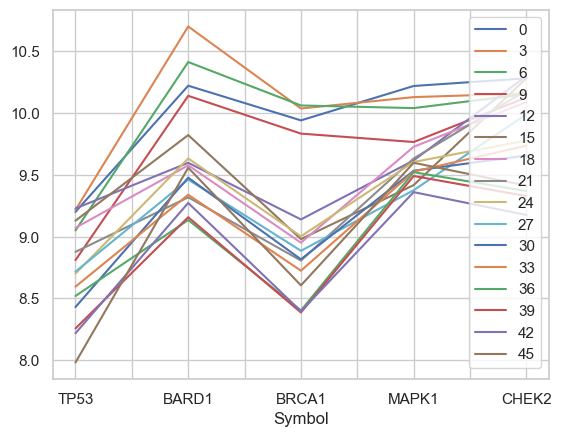

In [36]:
df_important_genes.plot()

<Axes: >

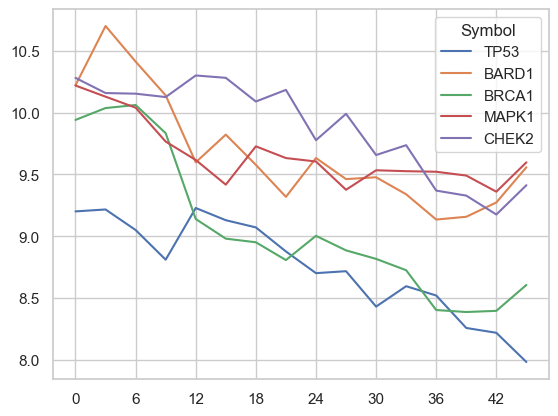

In [37]:
df_important_genes.T.plot()

<Axes: >

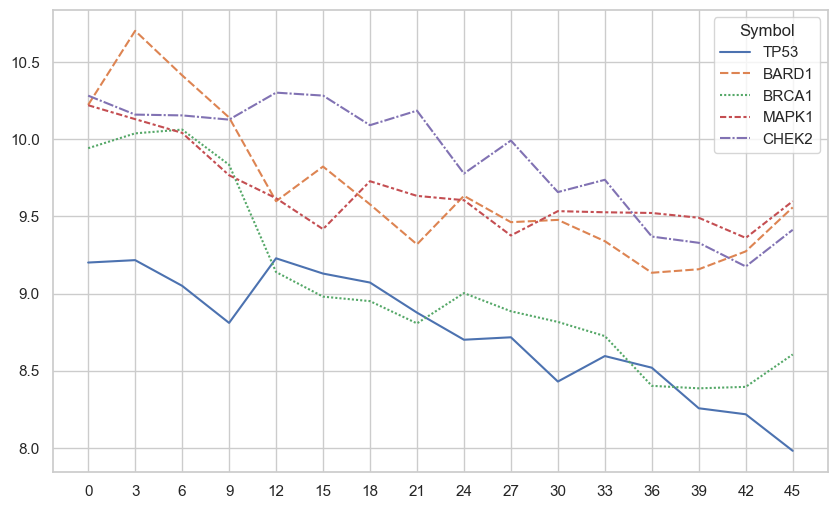

In [32]:
#plot the expression of the important genes
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of seaborn
sns.set(style='whitegrid')

# Create a figure and axis
plt.figure(figsize=(10, 6))

# Plot the expression of the important genes

sns.lineplot(data=df_expr.loc[important_genes, :].T)




### - Select only genes that have a standard dev > 0.7 and a change between hour 0 and hour 45 > 1.4 fold.


In [33]:
gene_sd = df_expr.T.std()
gene_sd


Symbol
ABCA1     0.634829
ABCC11    0.343696
ABCC3     0.803495
ABLIM1    0.355669
ABP1      0.483524
            ...   
ZNF606    0.257139
ZNF616    0.257465
ZNF83     0.375355
ZNFX1     0.369599
ZWINT     0.653463
Length: 1175, dtype: float64

In [34]:
r0_45 = df_expr.loc['TP53'] / df_expr.loc['BARD1']
c1 = gene_sd > 0.7
c2 = (r0_45 >1.4) | (1/r_0_45 > 1.4)

df_expr(c1 & c2)

NameError: name 'r_0_45' is not defined

____

[ClinVar][1] is a freely accessible, public archive of reports of the relationships among human variations and phenotypes, with supporting evidence.


The data you will be working with (`clinvar.vcf`).  More information about the database can be found [here][3].

From: https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/

Download the file clinvar.vcf.gz


### The file format
The beginning of every VCF file contains various sets of information:
* Meta-information (details about the experiment or configuration) lines start with **`##`**
    * These lines are helpful in understanding specialized keys found in the `INFO` column. It is in these sections that one can find:
        * The description of the key
        * The data type of the values
        * The default value of the values
* Header lines (column names) start with **`#`**

From there on, each line is made up of tab (`\t`) separated values that make up eight (8) columns. Those columns are:
1. CHROM (chromosome)
2. POS (base pair position of the variant)
3. ID (identifier if applicable; `.` if not applicable/missing)
4. REF (reference base)
5. ALT (alternate base(s): comma (`,`) separated if applicable)
6. QUAL (Phred-scaled quality score; `.` if not applicable/missing)
7. FILTER (filter status; `.` if not applicable/missing)
8. INFO (any additional information about the variant)
    * Semi-colon (`;`) separated key-value pairs
    * Key-value pairs are equal sign (`=`) separated (key on the left, value on the right)
    * If a key has multiple values, the values are pipe (`|`) separated

---
[1] https://www.ncbi.nlm.nih.gov/clinvar/intro/  
[2] https://samtools.github.io/hts-specs/VCFv4.3.pdf  
[3] http://exac.broadinstitute.org  



____

### <font color = "red">Exercise</font>

___

### - From the VCF file extract the variant position information and plot the distribution (histogram)


### - From the VCF file identify the genes for each variant from the info column GENEINFO key - write a function that identifies the genes for each variant




### - Select only the variants for our 5 genes of interest from the expression data frame TP53, BARD1, BRCA1, MAPK1, CHEK2

In [ ]:
important_genes = ("TP53", "BARD1", "BRCA1", "MAPK1", "CHEK2")